# 实践 1：资产的收益和风险度量（2026）

**题目（本学期幻灯片）**

1. 上证综指 SSCI、道琼斯工业 DJI、COMEX 黄金期货、CME 比特币期货：2006-01-01（或自有交易以来）至 **2025-12-31**。  
   蓝字「原理版」是 2024-01-01 至 2025-12-31 的两年子样本，默认不算，末尾可一键切换。
2. 每类资产每一年的收益和标准差；比较时变性、截面差异。
3. 历史模拟法：每个指数每一年的 95% 日 VaR、ES、下偏标准差。
4. （相关性）四类资产相关系数。对股市投资而言，黄金或比特币有避险效应吗？
5. 同组 2 人互相验证结果。

**提交**

- 邮箱 `bnu_invst@163.com`
- 命名 `实验1+038邓权艺+xxx组员`
- DDL **2026-09-27（日）24:00**

数据用课程发放的 `实践1数据-股指黄金比特币-2006至今.xlsx`（与 notebook 同级）。完整代码：https://github.com/aylmerwawa/investments-lab1-return-risk



## 口径（跟课件走）

日简单收益：

$$
r_t = \frac{P_t}{P_{t-1}} - 1
$$

**年度收益**（日历年、收盘到收盘）：该年所有日收益连乘。有上年年末价时，等于

$$
R_y = \frac{P_{\text{年末}}}{P_{\text{上年末}}} - 1
$$

2006 年样本里没有 2005，所以 2006 只能用当年首末收盘。

**年度标准差**：该年日收益样本标准差（`ddof=1`）再年化。主表用 $\sigma_{\mathrm{d}}\sqrt{n}$（$n$ 为该年日收益个数）；另给 $\sigma_{\mathrm{d}}\sqrt{250}$（课件平方根法则常用 250 日）。

**95% 日 VaR（历史模拟）**：该年日收益的 5% 分位数 $q_{0.05}$。表里同时给收益口径（负数）和损失口径 $-q_{0.05}$。

**ES（课件条件期望）**：

$$
\mathrm{ES}_{5\%} = E[r \mid r \le q_{0.05}]
$$

**下偏标准差（课件下偏方差再开方，阈值为该年日均收益 $\bar r$）**：

$$
\sigma_D = \sqrt{\frac{1}{N-1}\sum_t \max(0,\ \bar r - r_t)^2}
$$

相关主表用 **两两配对**，黄金能用满 2006–2025；四资产共同样本（比特币 2017-12 上市之后）另给一张，避免把股票–黄金的样本截断到比特币时代。

**拓展（非题面必交）方差–协方差**：第 2b 节。同一年样本 $\mu,\sigma$，假定 $r\sim N(\mu,\sigma^2)$。主表仍是历史模拟。


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
pd.set_option("display.max_rows", 30)

plt.rcParams["font.sans-serif"] = [
    "Source Han Sans SC",
    "Songti SC",
    "Hiragino Sans GB",
    "Arial Unicode MS",
]
plt.rcParams["axes.unicode_minus"] = False

BASE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
DATA = BASE / "实践1数据-股指黄金比特币-2006至今.xlsx"
OUT = BASE / "结果"
OUT.mkdir(exist_ok=True)

SAMPLE_START = "2006-01-01"
SAMPLE_END = "2025-12-31"   # 题面窗口；改成 None 则用文件里全部日期
SHORT_WINDOW = False        # True = 原理版 2024-01-01 ~ 2025-12-31

SHEETS = {
    "上证综指": "上证综指SSCI",
    "道琼斯": "道琼斯工业DJIA",
    "COMEX黄金": "COMEX黄金",
    "CME比特币": "CME-BTC",
}

print("数据文件:", DATA)
print("窗口:", SAMPLE_START, "→", SAMPLE_END, "| 原理版两年:", SHORT_WINDOW)


Matplotlib is building the font cache; this may take a moment.


数据文件: /Users/aylmerd/Documents/大三专业课/投资学/作业/实验1-收益与风险/2026/实践1数据-股指黄金比特币-2006至今.xlsx
窗口: 2006-01-01 → 2025-12-31 | 原理版两年: False


In [2]:
def pick_close(df: pd.DataFrame) -> str:
    for c in df.columns:
        s = str(c)
        if s in {"收盘", "收盘价", "收盘价(元)", "close"}:
            return c
    raise KeyError(f"找不到收盘价列: {list(df.columns)}")


def load_one(sheet: str, label: str) -> pd.DataFrame:
    raw = pd.read_excel(DATA, sheet_name=sheet)
    close_col = pick_close(raw)
    out: pd.DataFrame = pd.DataFrame(
        {
            "date": pd.to_datetime(raw["日期"]),
            "close": pd.to_numeric(raw[close_col], errors="coerce"),
            "name": raw["名称"] if "名称" in raw.columns else label,
            "code": raw["代码"] if "代码" in raw.columns else sheet,
        }
    )
    out = out.dropna(subset=["date", "close"]).sort_values("date")
    out = out.drop_duplicates(subset="date", keep="last")
    start, end = SAMPLE_START, SAMPLE_END
    if SHORT_WINDOW:
        start, end = "2024-01-01", "2025-12-31"
    if start:
        out = out.loc[out["date"] >= pd.Timestamp(start)]
    if end:
        out = out.loc[out["date"] <= pd.Timestamp(end)]
    out = out.reset_index(drop=True)
    out["r"] = out["close"].pct_change()
    out["year"] = out["date"].dt.year
    out["asset"] = label
    return out


assets = {label: load_one(sheet, label) for label, sheet in SHEETS.items()}

qc_rows = []
for label, df in assets.items():
    r = df["r"].dropna()
    close = df["close"].to_numpy()
    qc_rows.append(
        {
            "资产": label,
            "代码": str(df["code"].iloc[0]),
            "名称": str(df["name"].iloc[0]),
            "起始": pd.Timestamp(df["date"].iloc[0]).date(),
            "结束": pd.Timestamp(df["date"].iloc[-1]).date(),
            "交易日": int(len(df)),
            "日收益条数": int(len(r)),
            "收盘≤0": int(np.count_nonzero(close <= 0)),
        }
    )
qc = pd.DataFrame(qc_rows)
qc.to_excel(OUT / "00-数据概览.xlsx", index=False)
qc


,资产,代码,名称,起始,结束,交易日,日收益条数,收盘≤0
0,上证综指,000001.SH,上证指数,2006-01-04,2025-12-31,4859,4858,0
1,道琼斯,DJI.GI,道琼斯工业指数,2006-01-03,2025-12-31,5031,5030,0
2,COMEX黄金,GC00.CMX,COMEX黄金连续,2006-01-03,2025-12-31,4919,4918,0
3,CME比特币,BTC.CME,CME比特币期货,2017-12-18,2025-12-31,2022,2021,0


### 样本说明

老师 Excel 里行情可以到 2026 年。题面窗口截到 **2025-12-31**，避免把未满年的 2026 和完整年放在同一张年表里。

黄金用 `GC00.CMX` 连续合约；比特币 `BTC.CME` 从 2017-12-18 起。年度指标要求该年日收益不少于 20 条，比特币 2017 年会被跳过。


## 1. 每年收益与标准差：时变 + 截面


In [3]:
def annual_stats(df: pd.DataFrame) -> pd.DataFrame:
    g = df.dropna(subset=["r"]).groupby("year")
    rows = []
    for year, x in g:
        r = x["r"]
        n = int(r.count())
        if n < 20:
            continue
        sigma_d = float(r.std(ddof=1))
        rows.append(
            {
                "year": int(year),
                "annual_return": float((1 + r).prod() - 1),
                "sigma_year": sigma_d * np.sqrt(n),
                "sigma_250": sigma_d * np.sqrt(250),
                "sigma_daily": sigma_d,
                "mean_daily": float(r.mean()),
                "n": n,
            }
        )
    return pd.DataFrame(rows)


annual = {k: annual_stats(v) for k, v in assets.items()}

annual_long = (
    pd.concat([df.assign(asset=k) for k, df in annual.items()], ignore_index=True)
    .sort_values(["asset", "year"])
)
annual_ret = annual_long.pivot(index="year", columns="asset", values="annual_return")
annual_sig = annual_long.pivot(index="year", columns="asset", values="sigma_year")

with pd.ExcelWriter(OUT / "01-年度收益与标准差.xlsx") as w:
    annual_ret.to_excel(w, sheet_name="年度收益")
    annual_sig.to_excel(w, sheet_name="年度波动_sqrt_n")
    annual_long.pivot(index="year", columns="asset", values="sigma_250").to_excel(
        w, sheet_name="年度波动_sqrt250"
    )
    annual_long.to_excel(w, sheet_name="明细", index=False)

print("=== 年度收益 ===")
display(annual_ret.style.format("{:.2%}"))
print("=== 年度波动 σ_d √n ===")
display(annual_sig.style.format("{:.2%}"))


=== 年度收益 ===


asset,CME比特币,COMEX黄金,上证综指,道琼斯
year,,,,
2006,nan%,19.21%,126.55%,14.90%
2007,nan%,31.03%,96.66%,6.43%
2008,nan%,9.26%,-65.39%,-33.84%
2009,nan%,23.26%,79.98%,18.82%
2010,nan%,28.98%,-14.31%,11.02%
2011,nan%,10.55%,-21.68%,5.53%
2012,nan%,6.89%,3.17%,7.26%
2013,nan%,-25.77%,-6.75%,26.50%
2014,nan%,-0.29%,52.87%,7.52%


=== 年度波动 σ_d √n ===


asset,CME比特币,COMEX黄金,上证综指,道琼斯
year,,,,
2006,nan%,23.69%,20.93%,9.78%
2007,nan%,16.57%,34.47%,14.50%
2008,nan%,31.15%,44.79%,37.95%
2009,nan%,22.23%,29.69%,24.23%
2010,nan%,14.97%,22.11%,16.16%
2011,nan%,20.01%,18.06%,21.02%
2012,nan%,15.10%,17.10%,11.75%
2013,nan%,20.64%,17.88%,10.16%
2014,nan%,15.96%,17.00%,10.88%


In [4]:
def summary_cross_section(annual_long: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for asset, df in annual_long.groupby("asset"):
        r = df["annual_return"]
        rows.append(
            {
                "资产": asset,
                "年数": len(df),
                "收益算术平均": r.mean(),
                "收益年际标准差": r.std(ddof=1),
                "最好一年": r.max(),
                "最差一年": r.min(),
                "正收益年比例": (r > 0).mean(),
                "波动算术平均": df["sigma_year"].mean(),
            }
        )
    return pd.DataFrame(rows).set_index("资产")


cs = summary_cross_section(annual_long)
cs.to_excel(OUT / "01b-截面摘要.xlsx")
print("各资产把每年当一个观测时的截面摘要（看时变有多大、谁更稳）")
display(cs.style.format("{:.2%}", subset=[c for c in cs.columns if c != "年数"]))


各资产把每年当一个观测时的截面摘要（看时变有多大、谁更稳）


,年数,收益算术平均,收益年际标准差,最好一年,最差一年,正收益年比例,波动算术平均
资产,,,,,,,
CME比特币,8,59.33%,108.49%,249.71%,-74.97%,62.50%,64.05%
COMEX黄金,20,12.45%,19.04%,66.15%,-25.77%,70.00%,17.11%
上证综指,20,14.17%,44.65%,126.55%,-65.39%,60.00%,21.23%
道琼斯,20,8.69%,13.69%,26.50%,-33.84%,80.00%,16.49%


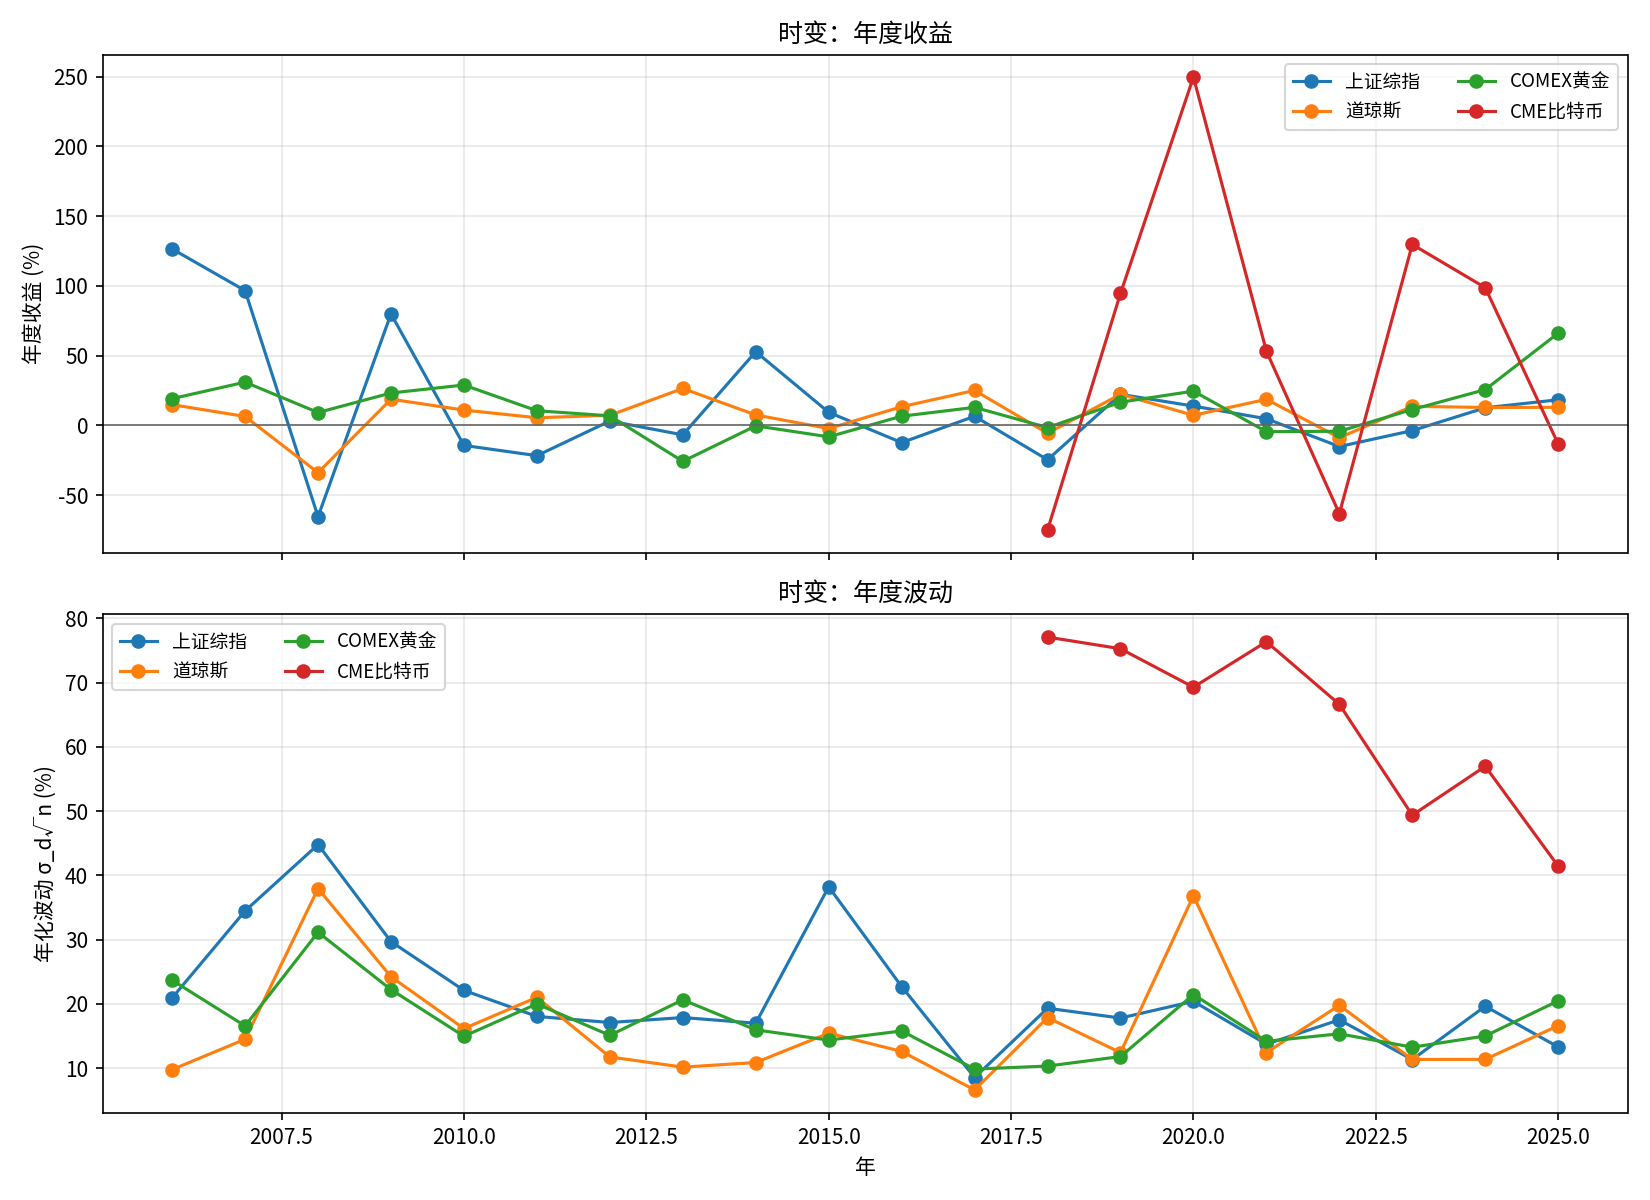

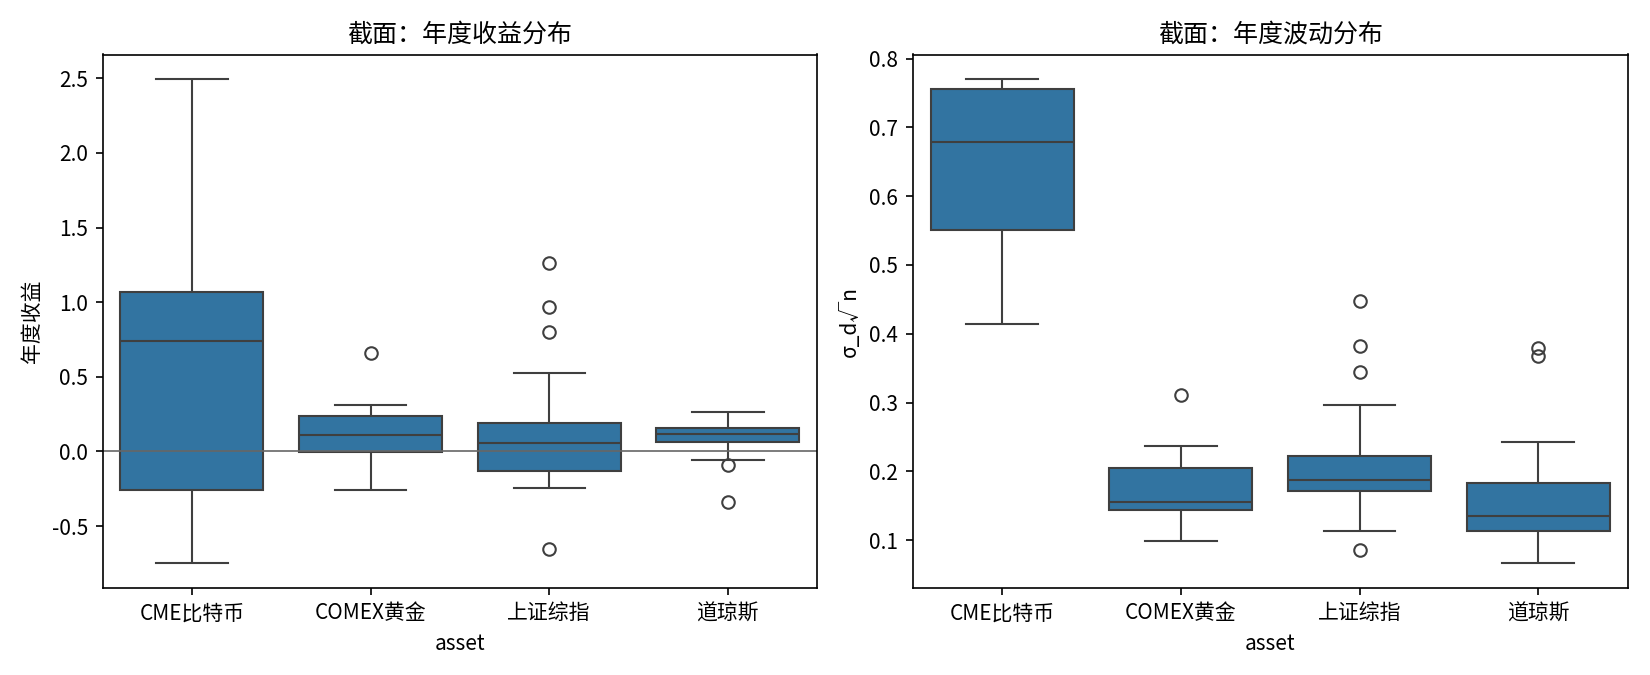

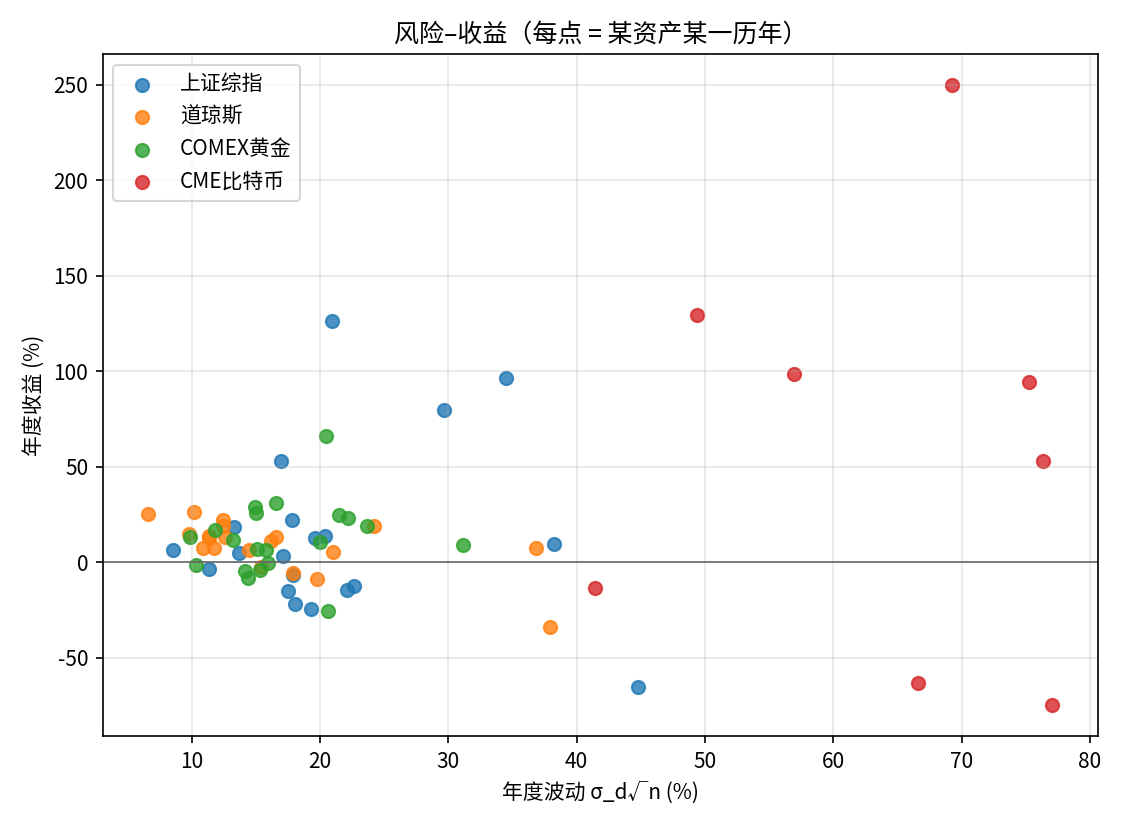

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for asset, df in annual.items():
    axes[0].plot(df["year"], df["annual_return"] * 100, marker="o", label=asset)
    axes[1].plot(df["year"], df["sigma_year"] * 100, marker="o", label=asset)
axes[0].axhline(0, color="0.4", lw=0.8)
axes[0].set_ylabel("年度收益 (%)")
axes[0].set_title("时变：年度收益")
axes[1].set_ylabel("年化波动 σ_d√n (%)")
axes[1].set_title("时变：年度波动")
axes[1].set_xlabel("年")
for ax in axes:
    ax.legend(ncol=2, fontsize=9)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "fig-01-时变-收益与波动.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(data=annual_long, x="asset", y="annual_return", ax=axes[0])
axes[0].axhline(0, color="0.4", lw=0.8)
axes[0].set_title("截面：年度收益分布")
axes[0].set_ylabel("年度收益")
sns.boxplot(data=annual_long, x="asset", y="sigma_year", ax=axes[1])
axes[1].set_title("截面：年度波动分布")
axes[1].set_ylabel("σ_d√n")
fig.tight_layout()
fig.savefig(OUT / "fig-01b-截面箱线图.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for asset, df in annual.items():
    ax.scatter(df["sigma_year"] * 100, df["annual_return"] * 100, s=40, alpha=0.8, label=asset)
ax.axhline(0, color="0.4", lw=0.8)
ax.set_xlabel("年度波动 σ_d√n (%)")
ax.set_ylabel("年度收益 (%)")
ax.set_title("风险–收益（每点 = 某资产某一历年）")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "fig-01c-风险收益散点.png", dpi=150)
plt.show()


## 2. 历史模拟：每年 95% 日 VaR、ES、下偏标准差

不假设正态。只把该年已经实现的日收益当成经验分布。交作业主表是这一节；2b 用方差–协方差做对照。


In [6]:
def risk_one_year(r: pd.Series) -> dict:
    r = r.dropna()
    n = int(r.count())
    q = float(np.quantile(r, 0.05))
    tail = r[r <= q]
    mu = float(r.mean())
    sv = float(np.sum(np.maximum(mu - r, 0.0) ** 2) / (n - 1))
    return {
        "n": n,
        "var_q": q,
        "var_loss": -q,
        "es_r": float(tail.mean()) if len(tail) else np.nan,
        "es_loss": float(-tail.mean()) if len(tail) else np.nan,
        "n_tail": int(len(tail)),
        "downside_std": float(np.sqrt(sv)),
        "sigma_daily": float(r.std(ddof=1)),
    }


def yearly_risk(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for year, x in df.dropna(subset=["r"]).groupby("year"):
        if len(x) < 20:
            continue
        row = risk_one_year(x["r"])
        row["year"] = int(year)
        rows.append(row)
    return pd.DataFrame(rows)


risk = {k: yearly_risk(v) for k, v in assets.items()}
risk_long = pd.concat([df.assign(asset=k) for k, df in risk.items()], ignore_index=True)

var_tbl = risk_long.pivot(index="year", columns="asset", values="var_loss")
es_tbl = risk_long.pivot(index="year", columns="asset", values="es_loss")
ds_tbl = risk_long.pivot(index="year", columns="asset", values="downside_std")

with pd.ExcelWriter(OUT / "02-年度风险指标.xlsx") as w:
    var_tbl.to_excel(w, sheet_name="VaR95_损失口径")
    es_tbl.to_excel(w, sheet_name="ES_损失口径")
    ds_tbl.to_excel(w, sheet_name="下偏标准差")
    risk_long.to_excel(w, sheet_name="明细", index=False)

print("95% 日 VaR（损失口径，正数 = 亏这么多）")
display(var_tbl.style.format("{:.2%}"))
print("ES（损失口径）")
display(es_tbl.style.format("{:.2%}"))
print("下偏标准差（日，课件阈值 = 当年日均收益）")
display(ds_tbl.style.format("{:.2%}"))


95% 日 VaR（损失口径，正数 = 亏这么多）


asset,CME比特币,COMEX黄金,上证综指,道琼斯
year,,,,
2006,nan%,2.40%,1.94%,0.94%
2007,nan%,1.73%,3.95%,1.67%
2008,nan%,2.83%,5.19%,3.92%
2009,nan%,2.38%,3.16%,2.42%
2010,nan%,1.50%,2.07%,1.49%
2011,nan%,2.32%,2.11%,2.20%
2012,nan%,1.44%,1.63%,1.12%
2013,nan%,2.04%,1.81%,0.94%
2014,nan%,1.69%,1.40%,1.14%


ES（损失口径）


asset,CME比特币,COMEX黄金,上证综指,道琼斯
year,,,,
2006,nan%,3.56%,2.99%,1.35%
2007,nan%,2.47%,5.30%,2.30%
2008,nan%,3.94%,6.07%,5.73%
2009,nan%,2.84%,4.39%,3.42%
2010,nan%,2.04%,3.50%,2.41%
2011,nan%,3.25%,2.74%,3.20%
2012,nan%,2.20%,2.03%,1.59%
2013,nan%,3.30%,2.77%,1.35%
2014,nan%,2.27%,2.19%,1.64%


下偏标准差（日，课件阈值 = 当年日均收益）


asset,CME比特币,COMEX黄金,上证综指,道琼斯
year,,,,
2006,nan%,1.14%,0.97%,0.44%
2007,nan%,0.78%,1.75%,0.70%
2008,nan%,1.34%,1.93%,1.64%
2009,nan%,0.97%,1.45%,1.08%
2010,nan%,0.70%,1.06%,0.73%
2011,nan%,0.97%,0.84%,0.99%
2012,nan%,0.68%,0.72%,0.52%
2013,nan%,1.02%,0.84%,0.46%
2014,nan%,0.73%,0.76%,0.51%


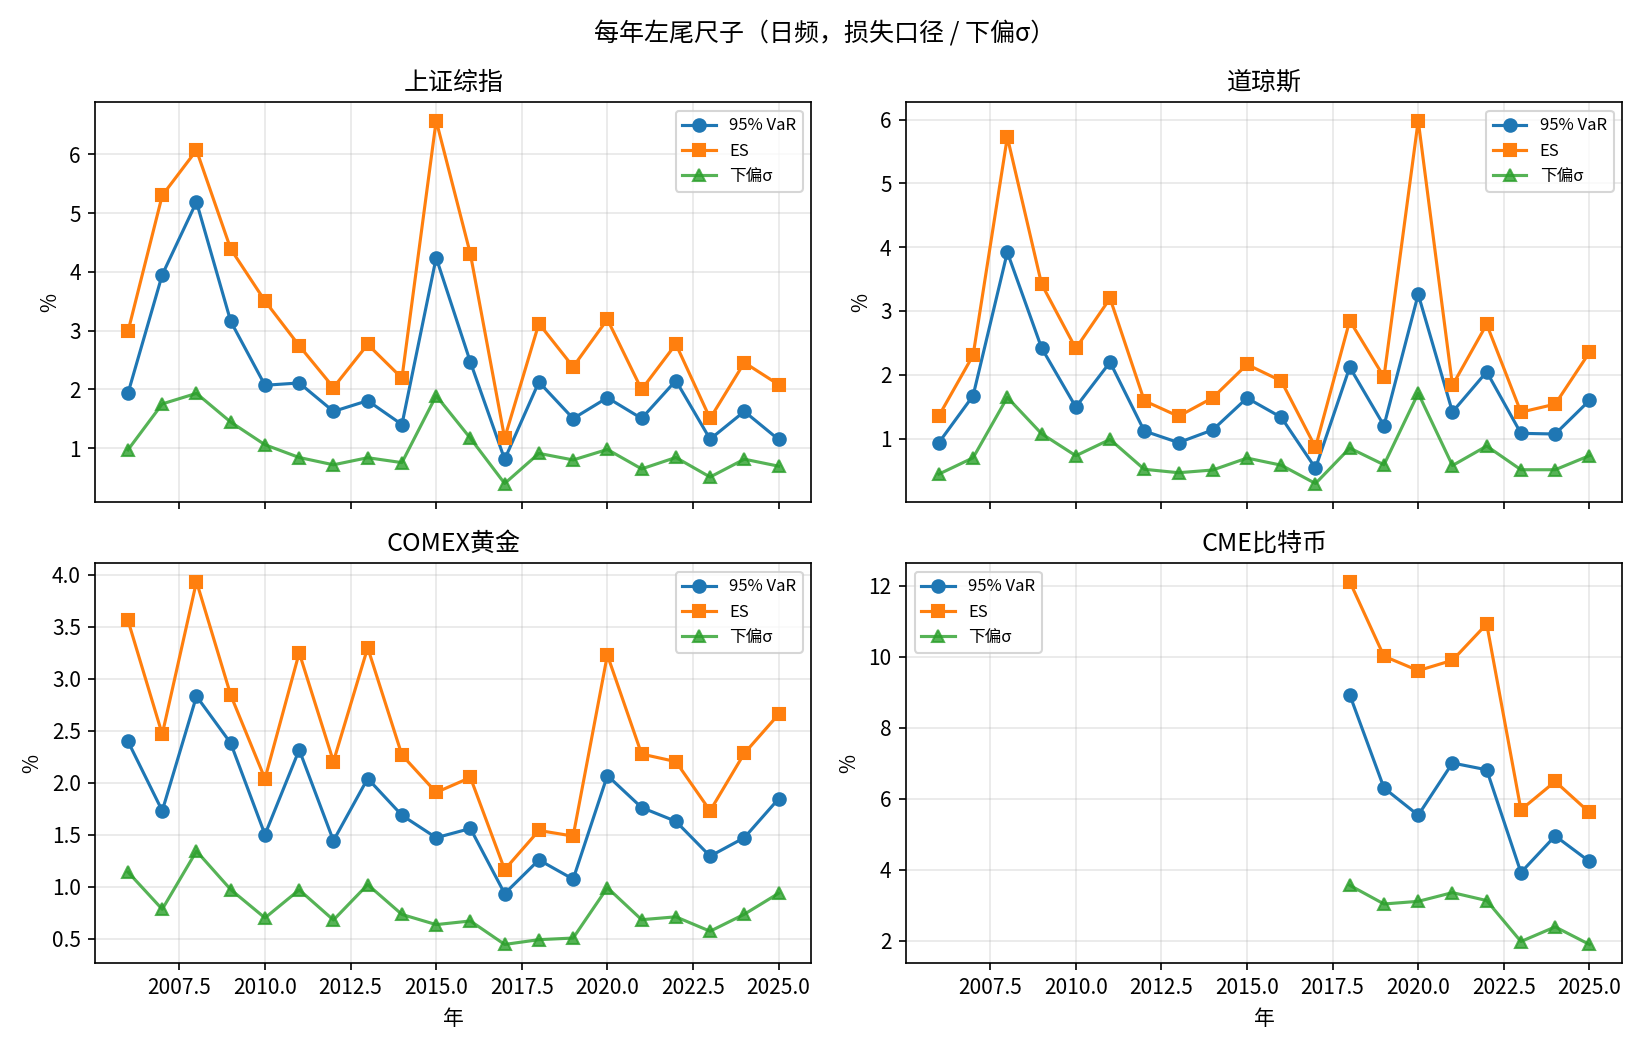

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
axes = axes.ravel()
for ax, (asset, df) in zip(axes, risk.items()):
    ax.plot(df["year"], df["var_loss"] * 100, marker="o", label="95% VaR")
    ax.plot(df["year"], df["es_loss"] * 100, marker="s", label="ES")
    ax.plot(df["year"], df["downside_std"] * 100, marker="^", label="下偏σ", alpha=0.8)
    ax.set_title(asset)
    ax.set_ylabel("%")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
axes[-1].set_xlabel("年")
axes[-2].set_xlabel("年")
fig.suptitle("每年左尾尺子（日频，损失口径 / 下偏σ）")
fig.tight_layout()
fig.savefig(OUT / "fig-02-年度VaR-ES-下偏.png", dpi=150)
plt.show()


## 2b. 拓展：方差–协方差（正态参数法，对照第 3 问）

交作业主表仍是上面的历史模拟。这里用课件 p35 的方差–协方差，按**同一年、同一批日收益**估 $\mu,\sigma$，再假设 $r\sim N(\mu,\sigma^2)$：

$$
q_{0.05}^{\mathrm{VC}}=\mu+z_{0.05}\sigma,\qquad z_{0.05}=\Phi^{-1}(0.05)\approx -1.645
$$

正态左尾的条件期望有闭式（和历史模拟的「左尾那些天再平均」同一口径）：

$$
\mathrm{ES}_{0.05}^{\mathrm{VC}}=E[r\mid r\le q]=\mu-\sigma\frac{\phi(z_{0.05})}{0.05}
$$

表里仍用损失口径（取负）。课件 IBM 短持有期常用 $\mu=0$；明细表一并给出。日均 $\mu$ 远小于 $\sigma$ 时两条几乎重合。

若真实左尾比正态肥，历史模拟的 VaR / ES 会大于参数法——对照的意义就在这里。


In [8]:
from scipy.stats import norm

ALPHA = 0.05
Z05 = float(norm.ppf(ALPHA))
PHI05 = float(norm.pdf(Z05))


def vc_one_year(r: pd.Series) -> dict:
    r = r.dropna()
    mu = float(r.mean())
    sig = float(r.std(ddof=1))
    q = mu + Z05 * sig
    es = mu - sig * PHI05 / ALPHA
    q0 = Z05 * sig
    es0 = -sig * PHI05 / ALPHA
    return {
        "mu": mu,
        "var_vc": -q,
        "es_vc": -es,
        "var_vc_mu0": -q0,
        "es_vc_mu0": -es0,
    }


vc_rows = []
for k, df in assets.items():
    for year, x in df.dropna(subset=["r"]).groupby("year"):
        if len(x) < 20:
            continue
        row = vc_one_year(x["r"])
        row["year"] = int(year)
        row["asset"] = k
        vc_rows.append(row)

vc_long = pd.DataFrame(vc_rows)
cmp = risk_long.merge(vc_long, on=["year", "asset"])
cmp["var_gap"] = cmp["var_loss"] - cmp["var_vc"]
cmp["es_gap"] = cmp["es_loss"] - cmp["es_vc"]

vc_var = cmp.pivot(index="year", columns="asset", values="var_vc")
hs_minus_vc = cmp.pivot(index="year", columns="asset", values="var_gap")

with pd.ExcelWriter(OUT / "02b-方差协方差对照.xlsx") as w:
    var_tbl.to_excel(w, sheet_name="VaR_历史模拟")
    vc_var.to_excel(w, sheet_name="VaR_方差协方差")
    hs_minus_vc.to_excel(w, sheet_name="VaR_HS减VC")
    cmp.pivot(index="year", columns="asset", values="es_vc").to_excel(
        w, sheet_name="ES_方差协方差"
    )
    cmp.to_excel(w, sheet_name="明细", index=False)

print(f"正态 95%：z = {Z05:.4f}，φ(z)/α = {PHI05 / ALPHA:.4f}（μ=0 时 ES ≈ 此倍数 × σ）")
print("μ=0 与含 μ 的日 VaR 最大相差", f"{(cmp['var_vc'] - cmp['var_vc_mu0']).abs().max():.4%}")
print("95% 日 VaR · 方差–协方差（损失口径，含 μ）")
display(vc_var.style.format("{:.2%}"))
print("历史模拟 − 方差–协方差（>0 表示经验左尾比正态更肥）")
display(hs_minus_vc.style.format("{:.2%}"))
print("按资产平均：")
display(
    cmp.groupby("asset")[["var_loss", "var_vc", "var_gap", "es_loss", "es_vc", "es_gap"]]
    .mean()
    .style.format("{:.2%}")
)


正态 95%：z = -1.6449，φ(z)/α = 2.0627（μ=0 时 ES ≈ 此倍数 × σ）
μ=0 与含 μ 的日 VaR 最大相差 0.5925%
95% 日 VaR · 方差–协方差（损失口径，含 μ）


asset,CME比特币,COMEX黄金,上证综指,道琼斯
year,,,,
2006,nan%,2.39%,1.87%,0.96%
2007,nan%,1.61%,3.34%,1.48%
2008,nan%,3.17%,5.09%,4.06%
2009,nan%,2.21%,2.87%,2.43%
2010,nan%,1.45%,2.39%,1.63%
2011,nan%,2.03%,1.99%,2.15%
2012,nan%,1.54%,1.79%,1.19%
2013,nan%,2.29%,1.93%,0.96%
2014,nan%,1.71%,1.61%,1.10%


历史模拟 − 方差–协方差（>0 表示经验左尾比正态更肥）


asset,CME比特币,COMEX黄金,上证综指,道琼斯
year,,,,
2006,nan%,0.01%,0.06%,-0.03%
2007,nan%,0.12%,0.61%,0.19%
2008,nan%,-0.33%,0.10%,-0.14%
2009,nan%,0.17%,0.29%,-0.01%
2010,nan%,0.05%,-0.32%,-0.13%
2011,nan%,0.29%,0.12%,0.05%
2012,nan%,-0.10%,-0.16%,-0.07%
2013,nan%,-0.25%,-0.12%,-0.02%
2014,nan%,-0.03%,-0.20%,0.04%


按资产平均：


,var_loss,var_vc,var_gap,es_loss,es_vc,es_gap
asset,,,,,,
CME比特币,5.96%,6.49%,-0.53%,8.79%,8.17%,0.62%
COMEX黄金,1.73%,1.74%,-0.01%,2.42%,2.20%,0.22%
上证综指,2.19%,2.20%,-0.01%,3.18%,2.77%,0.40%
道琼斯,1.66%,1.67%,-0.02%,2.43%,2.11%,0.33%


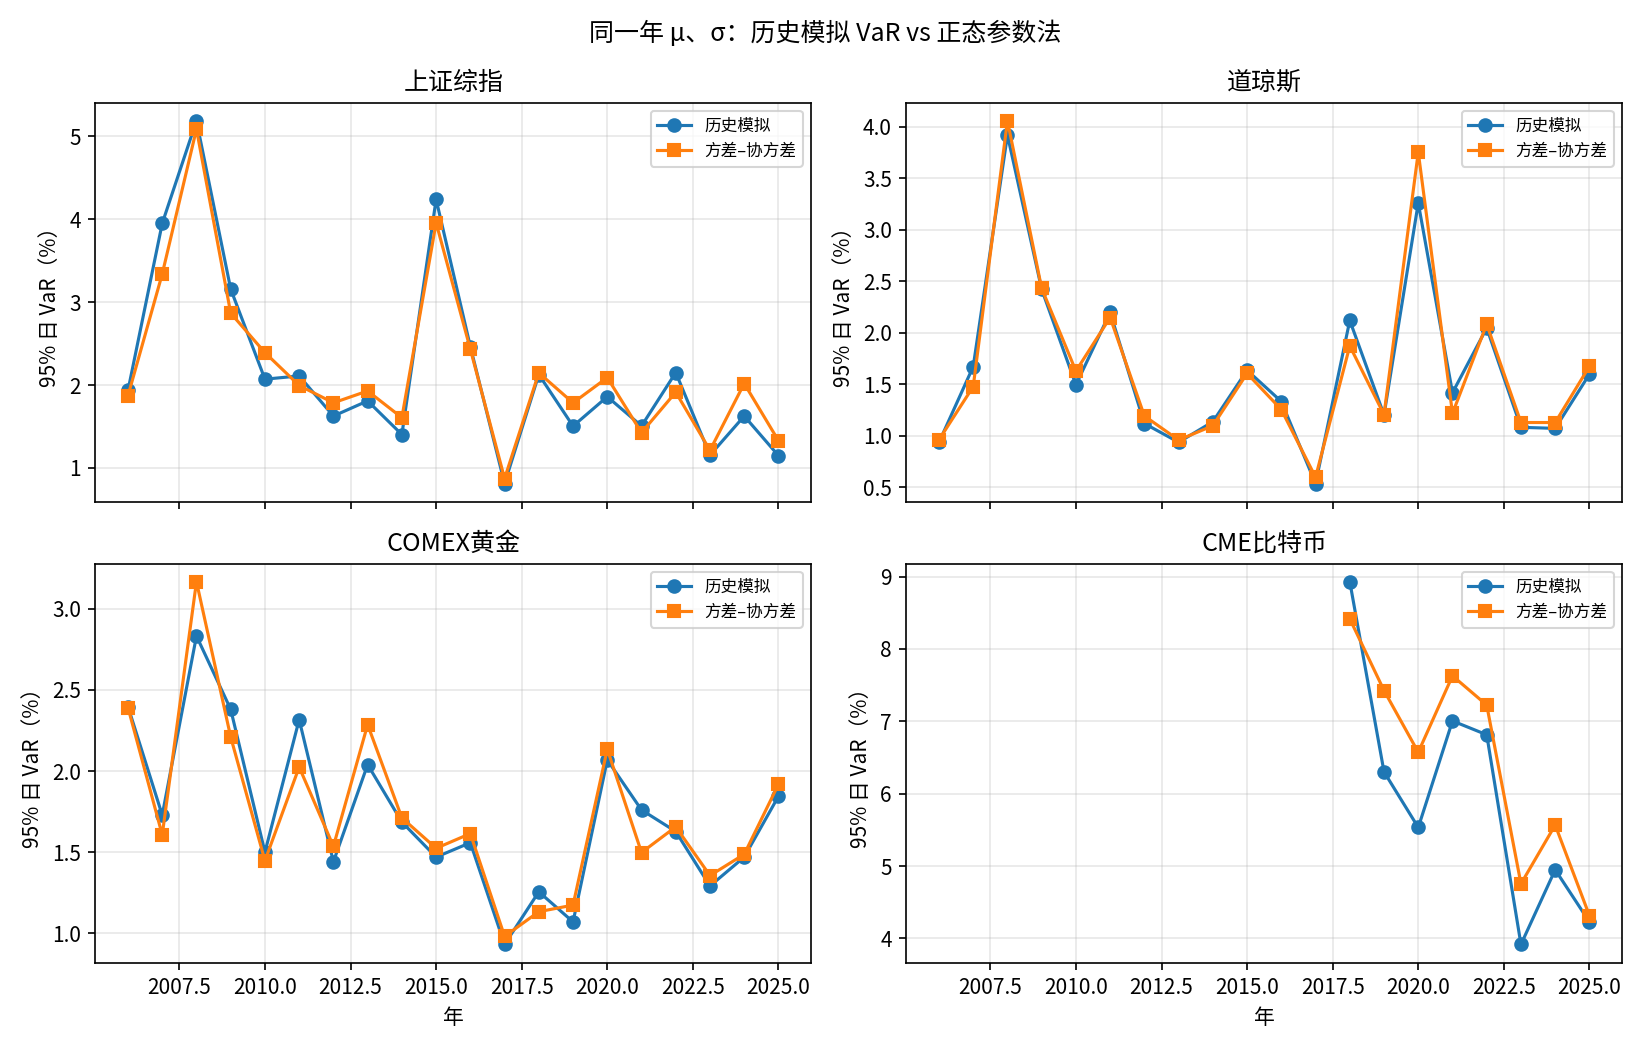

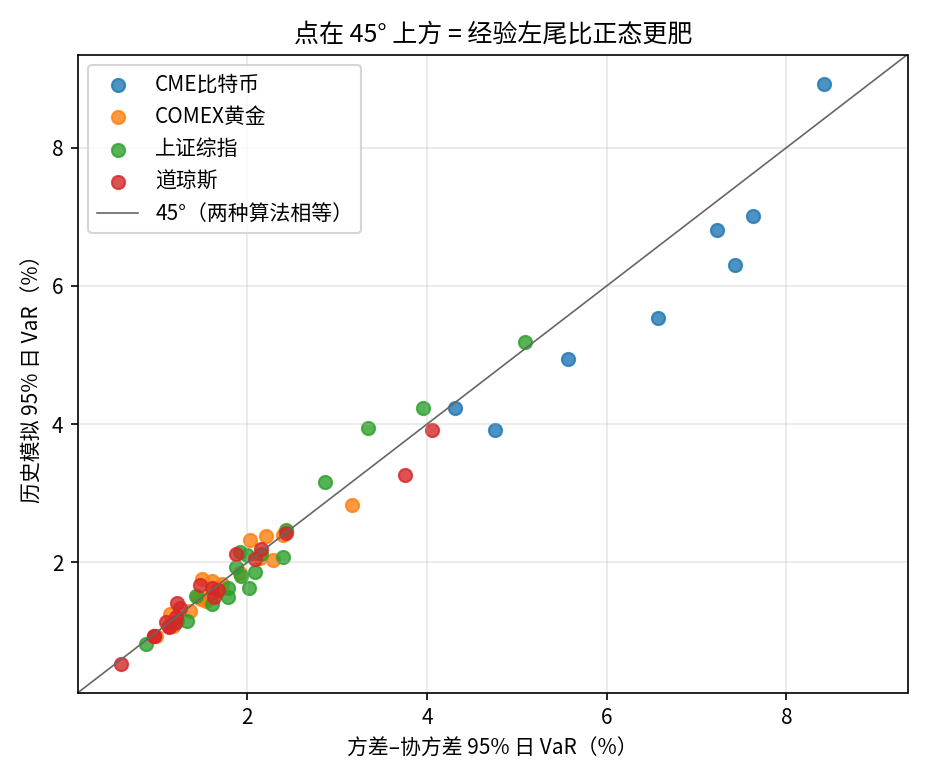

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
axes = axes.ravel()
for ax, asset in zip(axes, SHEETS):
    g = cmp.loc[cmp["asset"] == asset].sort_values("year")
    ax.plot(g["year"], g["var_loss"] * 100, marker="o", label="历史模拟")
    ax.plot(g["year"], g["var_vc"] * 100, marker="s", label="方差–协方差")
    ax.set_title(asset)
    ax.set_ylabel("95% 日 VaR（%）")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
axes[-1].set_xlabel("年")
axes[-2].set_xlabel("年")
fig.suptitle("同一年 μ、σ：历史模拟 VaR vs 正态参数法")
fig.tight_layout()
fig.savefig(OUT / "fig-02b-VaR-历史vs方差协方差.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6.2, 5.2))
for asset, g in cmp.groupby("asset"):
    ax.scatter(g["var_vc"] * 100, g["var_loss"] * 100, s=40, alpha=0.8, label=asset)
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, color="0.4", lw=0.8, label="45°（两种算法相等）")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("方差–协方差 95% 日 VaR（%）")
ax.set_ylabel("历史模拟 95% 日 VaR（%）")
ax.set_title("点在 45° 上方 = 经验左尾比正态更肥")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "fig-02c-VaR-历史vsVC散点.png", dpi=150)
plt.show()


## 3. 相关系数与避险

避险：股市大跌时，该资产倾向于上涨（条件相关为负，且大跌日自身均值为正）。  
只是相关低：分散化，还够不上「避险」。  
相关为正：更像同一风险因子，对冲股市没用。

主表 = 两两配对（黄金用满 2006–2025，比特币从 2017-12 起）。  
附录 = 四列都非空的共同样本（大约 2018 以后）。


In [10]:
wide = pd.concat(
    {k: v.set_index("date")["r"] for k, v in assets.items()},
    axis=1,
).sort_index()

corr_pair = wide.corr()          # pandas 默认 pairwise
corr_common = wide.dropna().corr()
n_pair = wide.notna().astype(int).T @ wide.notna().astype(int)
n_common = int(wide.dropna().shape[0])

print(f"两两配对样本量：\n{n_pair}\n")
print(f"四资产共同样本 n = {n_common}")
print("\n相关系数（pairwise）")
display(corr_pair.style.format("{:.3f}").background_gradient(cmap="coolwarm", vmin=-1, vmax=1))
print("相关系数（四列 listwise，比特币时代）")
display(corr_common.style.format("{:.3f}").background_gradient(cmap="coolwarm", vmin=-1, vmax=1))

with pd.ExcelWriter(OUT / "03-相关系数.xlsx") as w:
    corr_pair.to_excel(w, sheet_name="pairwise")
    corr_common.to_excel(w, sheet_name="listwise_四资产")
    n_pair.to_excel(w, sheet_name="pairwise样本量")


两两配对样本量：
         上证综指   道琼斯  COMEX黄金  CME比特币
上证综指     4858  4695     4593    1884
道琼斯      4695  5030     4901    2016
COMEX黄金  4593  4901     4918    1935
CME比特币   1884  2016     1935    2021

四资产共同样本 n = 1801

相关系数（pairwise）


/var/folders/81/pspyyp914hld9zpt3s18_cyr0000gn/T/ipykernel_2358/1576767278.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  wide = pd.concat(


,上证综指,道琼斯,COMEX黄金,CME比特币
上证综指,1.000,0.098,0.044,0.062
道琼斯,0.098,1.000,0.015,0.240
COMEX黄金,0.044,0.015,1.000,0.120
CME比特币,0.062,0.240,0.120,1.000


相关系数（四列 listwise，比特币时代）


,上证综指,道琼斯,COMEX黄金,CME比特币
上证综指,1.000,0.131,0.098,0.059
道琼斯,0.131,1.000,0.039,0.241
COMEX黄金,0.098,0.039,1.000,0.128
CME比特币,0.059,0.241,0.128,1.000


In [11]:
fig, ax = plt.subplots(figsize=(6.2, 5.2))
sns.heatmap(corr_pair, annot=True, fmt=".3f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("日收益相关系数（两两配对）")
fig.tight_layout()
fig.savefig(OUT / "fig-03-相关热力图.png", dpi=150)
plt.show()

stocks = ["上证综指", "道琼斯"]
hedges = ["COMEX黄金", "CME比特币"]
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, stock in zip(axes, stocks):
    for h in hedges:
        pair = wide[[stock, h]].dropna()
        roll = pair[stock].rolling(252, min_periods=120).corr(pair[h])
        ax.plot(roll.index, roll, label=h)
    ax.axhline(0, color="0.3", lw=0.8)
    ax.set_title(f"{stock} 与黄金 / 比特币：252 日滚动相关")
    ax.set_ylabel("ρ")
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "fig-03b-滚动相关.png", dpi=150)
plt.show()


In [12]:
CRASH = -0.02  # 该股市当日亏超过 2%
crash_rows = []
for stock in stocks:
    for h in hedges:
        pair = wide[[stock, h]].dropna()
        crash = pair[pair[stock] < CRASH]
        if crash.empty:
            continue
        crash_rows.append(
            {
                "股市": stock,
                "候选": h,
                "全样本ρ": pair[stock].corr(pair[h]),
                "大跌日ρ": crash[stock].corr(crash[h]),
                "大跌日数": len(crash),
                "大跌日候选均值": crash[h].mean(),
                "大跌日候选上涨比例": (crash[h] > 0).mean(),
            }
        )
crash_tbl = pd.DataFrame(crash_rows)
crash_tbl.to_excel(OUT / "03b-大跌日避险.xlsx", index=False)

print("全样本相关 vs 股市单日跌超 2% 时的条件表现")
display(
    crash_tbl.style.format(
        {
            "全样本ρ": "{:.3f}",
            "大跌日ρ": "{:.3f}",
            "大跌日候选均值": "{:.2%}",
            "大跌日候选上涨比例": "{:.1%}",
        }
    )
)

print("\n危机年（年度收益，不是日）对照：2008 / 2015 / 2020 / 2022")
crisis = annual_ret.loc[annual_ret.index.intersection([2008, 2015, 2020, 2022])]
display(crisis.style.format("{:.2%}"))


全样本相关 vs 股市单日跌超 2% 时的条件表现


,股市,候选,全样本ρ,大跌日ρ,大跌日数,大跌日候选均值,大跌日候选上涨比例
0,上证综指,COMEX黄金,0.044,0.033,288,-0.02%,46.5%
1,上证综指,CME比特币,0.062,0.113,59,-0.22%,40.7%
2,道琼斯,COMEX黄金,0.015,0.116,179,0.17%,52.0%
3,道琼斯,CME比特币,0.240,0.355,71,-2.69%,22.5%



危机年（年度收益，不是日）对照：2008 / 2015 / 2020 / 2022


asset,CME比特币,COMEX黄金,上证综指,道琼斯
year,,,,
2008,nan%,9.26%,-65.39%,-33.84%
2015,nan%,-8.16%,9.41%,-2.23%
2020,249.71%,24.59%,13.87%,7.25%
2022,-63.26%,-4.17%,-15.13%,-8.78%


## 4. 写进报告前先填的判断（跑完上面再改）

时变 / 截面

- 波动最高的通常是比特币，黄金居中，道指往往比上证更稳。
- 2008、2015（A 股）、2020、2022 应在年收益和 VaR 上都看得见。

避险（以第 3 问表为准，不要提前背结论）

- 黄金对美股：历史上常被当成避险；看全样本 ρ 和大跌日均值符号是否一致。
- 黄金对 A 股：相关往往更弱，未必等于「A 股崩了黄金就涨」。
- 比特币：上市后多数时期更像风险资产；若大跌日 ρ 仍为正、自身均值为负，就不要写成避险。

组员互核

- 年度收益：抽 2015 上证、2008 道指、2020 黄金、2021 比特币，两人对到小数点后 3 位（百分数后 1 位）。
- VaR：同一年 `n_tail` 应约为 `0.05 n`（250 日大约 12–13 个）。
- 拓展对照：95% VaR 两种算法多数年份接近；真正拉开的是 ES（2015 上证历史模拟 ES 应明显高于正态）。不要默认「历史模拟 VaR 一定更大」。
- 相关：确认用的是 pairwise 还是四列共同样本；两种数字都会差一截，报告里写明。


In [13]:
print("已写入", OUT)
for p in sorted(OUT.glob("*")):
    print(" ", p.name)


已写入 /Users/aylmerd/Documents/大三专业课/投资学/作业/实验1-收益与风险/2026/结果
  00-数据概览.xlsx
  01-年度收益与标准差.xlsx
  01b-截面摘要.xlsx
  02-年度风险指标.xlsx
  02b-方差协方差对照.xlsx
  03-相关系数.xlsx
  03b-大跌日避险.xlsx
  fig-01-时变-收益与波动.png
  fig-01b-截面箱线图.png
  fig-01c-风险收益散点.png
  fig-02-年度VaR-ES-下偏.png
  fig-02b-VaR-历史vs方差协方差.png
  fig-02c-VaR-历史vsVC散点.png
  fig-03-相关热力图.png
  fig-03b-滚动相关.png
